## Supplementary Figure 8

Enviorment: env 1

In [1]:
# env 1
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
import colorsys
import matplotlib as mpl

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary-AI-HDP/code/utils/")
from utils import bl_clean, wrap_labels, bl_to_cat

In [2]:
fontsize=12

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"
dpi = 300

In [3]:
def parse_param_string(s: str) -> dict:
    s = s.strip().strip('"').strip("'")
    if s.startswith("{") and s.endswith("}"):
        s = s[1:-1]

    params = {}
    for item in s.split(","):
        item = item.strip()
        if not item:
            continue
        key, val = item.rsplit("_", 1)
        params[key] = val
    return params

In [4]:
def get_pw_feat_imp_comps(data_name, run, ml_metrics=None):
    if ml_metrics is None:
        ml_metrics = pd.read_csv(f"{data_path}/{data_name}/{run}/meta_probs_auc_0.5/all_pw_metrics.csv").drop(columns="Unnamed: 0")
        ml_metrics = ml_metrics.loc[
            ml_metrics[["pw", "auc"]].groupby("pw").idxmax()["auc"]
        ]
    
    avg_feat_imp = []
    all_hp_data = []
    all_feat_imps_dfs = []

    category_color_map = {
        'Graph':        '#c43f94',
        'Geometry':     '#59a947',
        'Nesting Tree': '#337ec1',
        'Complexity':   '#e78829',
        'Mixed':        '#aaaaaa',
    }

    def darken_color(color, factor=0.6):
        """Return a darker version of the given color by reducing lightness."""
        r, g, b, a = to_rgba(color)
        h, l, s = colorsys.rgb_to_hls(r, g, b)
        l = max(0, l * factor)
        r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
        return (r2, g2, b2, a)

    category_edge_color_map = {
        cat: darken_color(color)
        for cat, color in category_color_map.items()
    }

    def get_category(feat_name):
        """Look up the category for a (cleaned) feature name via bl_to_cat."""
        return bl_to_cat.get(feat_name, 'Mixed')

    all_data_list = []
    for i in range(5):
        row = ml_metrics.iloc[i]
        hp = row["hp"]
        path = f"{data_path}/{data_name}{i + 1}/{run}/meta_probs_auc_0.5/XGBoost/{hp}_oof.pkl"
        with open(path, "rb") as f:
            data = pickle.load(f)
        all_data_list.append(data)

    for i in range(5):
        fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True, dpi=dpi)
        row = ml_metrics.iloc[i]
        pw  = row["pw"]
        hp  = row["hp"]
        print(f"PW{pw}")
        print(hp)
        all_hp_data.append(parse_param_string(hp))

        data = all_data_list[i]
        feat_imps = []

        cleaned_to_category = {}
        for idx in range(len(list(data[0].keys()))):
            raw_feats     = data[3][idx]
            cleaned_feats = data[3][idx].map(bl_clean)
            for raw, cleaned in zip(raw_feats, cleaned_feats):
                cat = bl_to_cat.get(raw, 'Mixed')
                cleaned_to_category[cleaned] = cat

        def get_category(feat_name):
            return cleaned_to_category.get(feat_name, 'Mixed')

        print(f"there are {len(list(data[0].keys()))} ids")
        for idx in range(len(list(data[0].keys()))):
            id_           = list(data[0].keys())[idx]
            cleaned_feats = data[3][idx].map(bl_clean)
            imp           = data[6][id_].feature_importances_
            imp           = imp / sum(imp)
            feat_imps.append(dict(zip(cleaned_feats, imp)))

        print(f"there are {len(feat_imps)} feature imps")
        feat_imps_df = pd.DataFrame(feat_imps).fillna(0)
        print(f"there are {len(feat_imps_df.columns)} columns")
        avg_feat_imp.append(feat_imps_df.mean().sort_values(ascending=False))

        order       = list(feat_imps_df.mean().sort_values(ascending=False).index)
        palette     = [category_color_map.get(get_category(feat), '#aaaaaa') for feat in order]
        edge_colors = [category_edge_color_map.get(get_category(feat), darken_color('#aaaaaa')) for feat in order]

        flierprops = dict(marker='D', markersize=4)
        sns.boxplot(feat_imps_df, order=order, palette=palette, ax=ax,
                    flierprops=flierprops)

        for j, patch in enumerate(ax.patches[:len(order)]):
            patch.set_edgecolor(edge_colors[j])
            patch.set_linewidth(2)

        whiskers      = ax.lines
        lines_per_box = len(whiskers) // len(order) if len(order) > 0 else 6
        for j in range(len(order)):
            edge_col = edge_colors[j]
            for k in range(lines_per_box):
                idx2 = j * lines_per_box + k
                if idx2 < len(whiskers):
                    line = whiskers[idx2]
                    if line.get_marker() in ('D', 'd'):
                        line.set_markerfacecolor(edge_col)
                        line.set_markeredgecolor(edge_col)
                    else:
                        line.set_color(edge_col)
                        line.set_linewidth(1.5)

        labels         = ax.get_xticklabels()
        wrapped_labels = wrap_labels([label.get_text() for label in labels], 20)
        ax.set_xticklabels(wrapped_labels)

        plt.xticks(rotation=90, ha='center', va='top')
        ax.tick_params(axis='x', pad=0)
        for label in ax.get_xticklabels():
            label.set_rotation(90)
            label.set_va('top')
            label.set_ha('center')

        plt.title(f"PW{pw} LOOCV Meta-Learner Base Learner Importance")
        plt.savefig(
            f'/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_8/pw_{pw}.pdf',
            bbox_inches='tight'
        )
        plt.show()

    return avg_feat_imp

In [5]:
data_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/"
run = "run_20260407_stable"
data_name = "rev_strat_pec_hc_pw"

PW1
{n_estimators_250,max_depth_3,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_8}
there are 281 ids
there are 281 feature imps
there are 16 columns


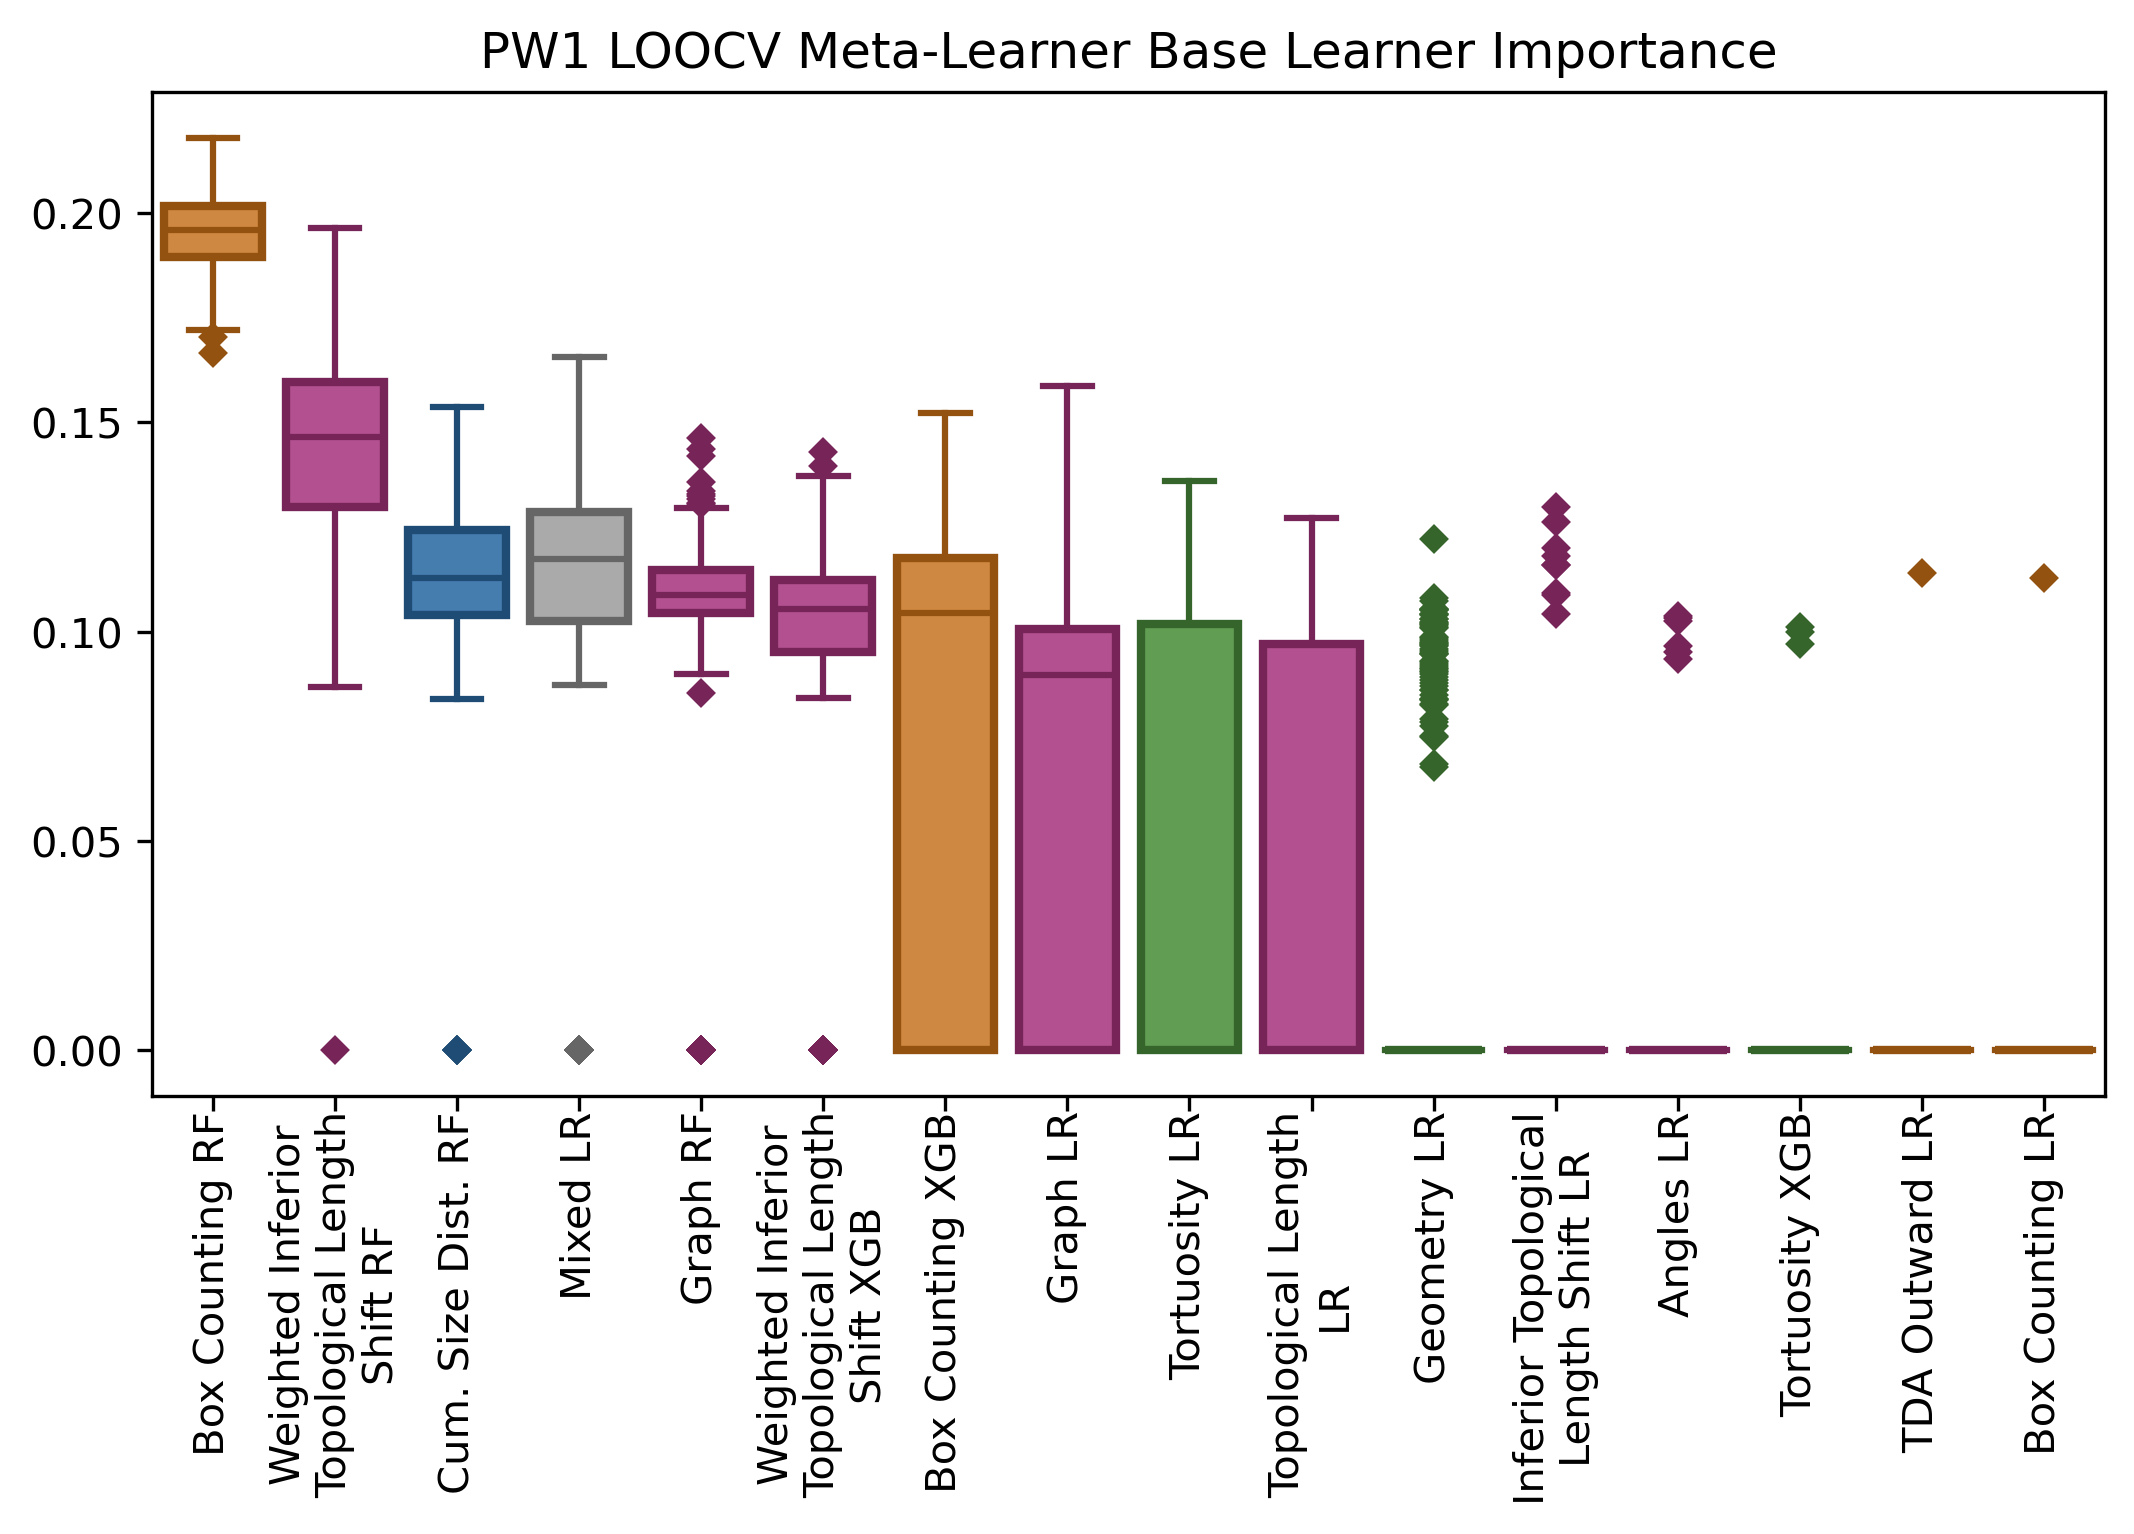

PW2
{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_12,n_feats_8}
there are 280 ids
there are 280 feature imps
there are 17 columns


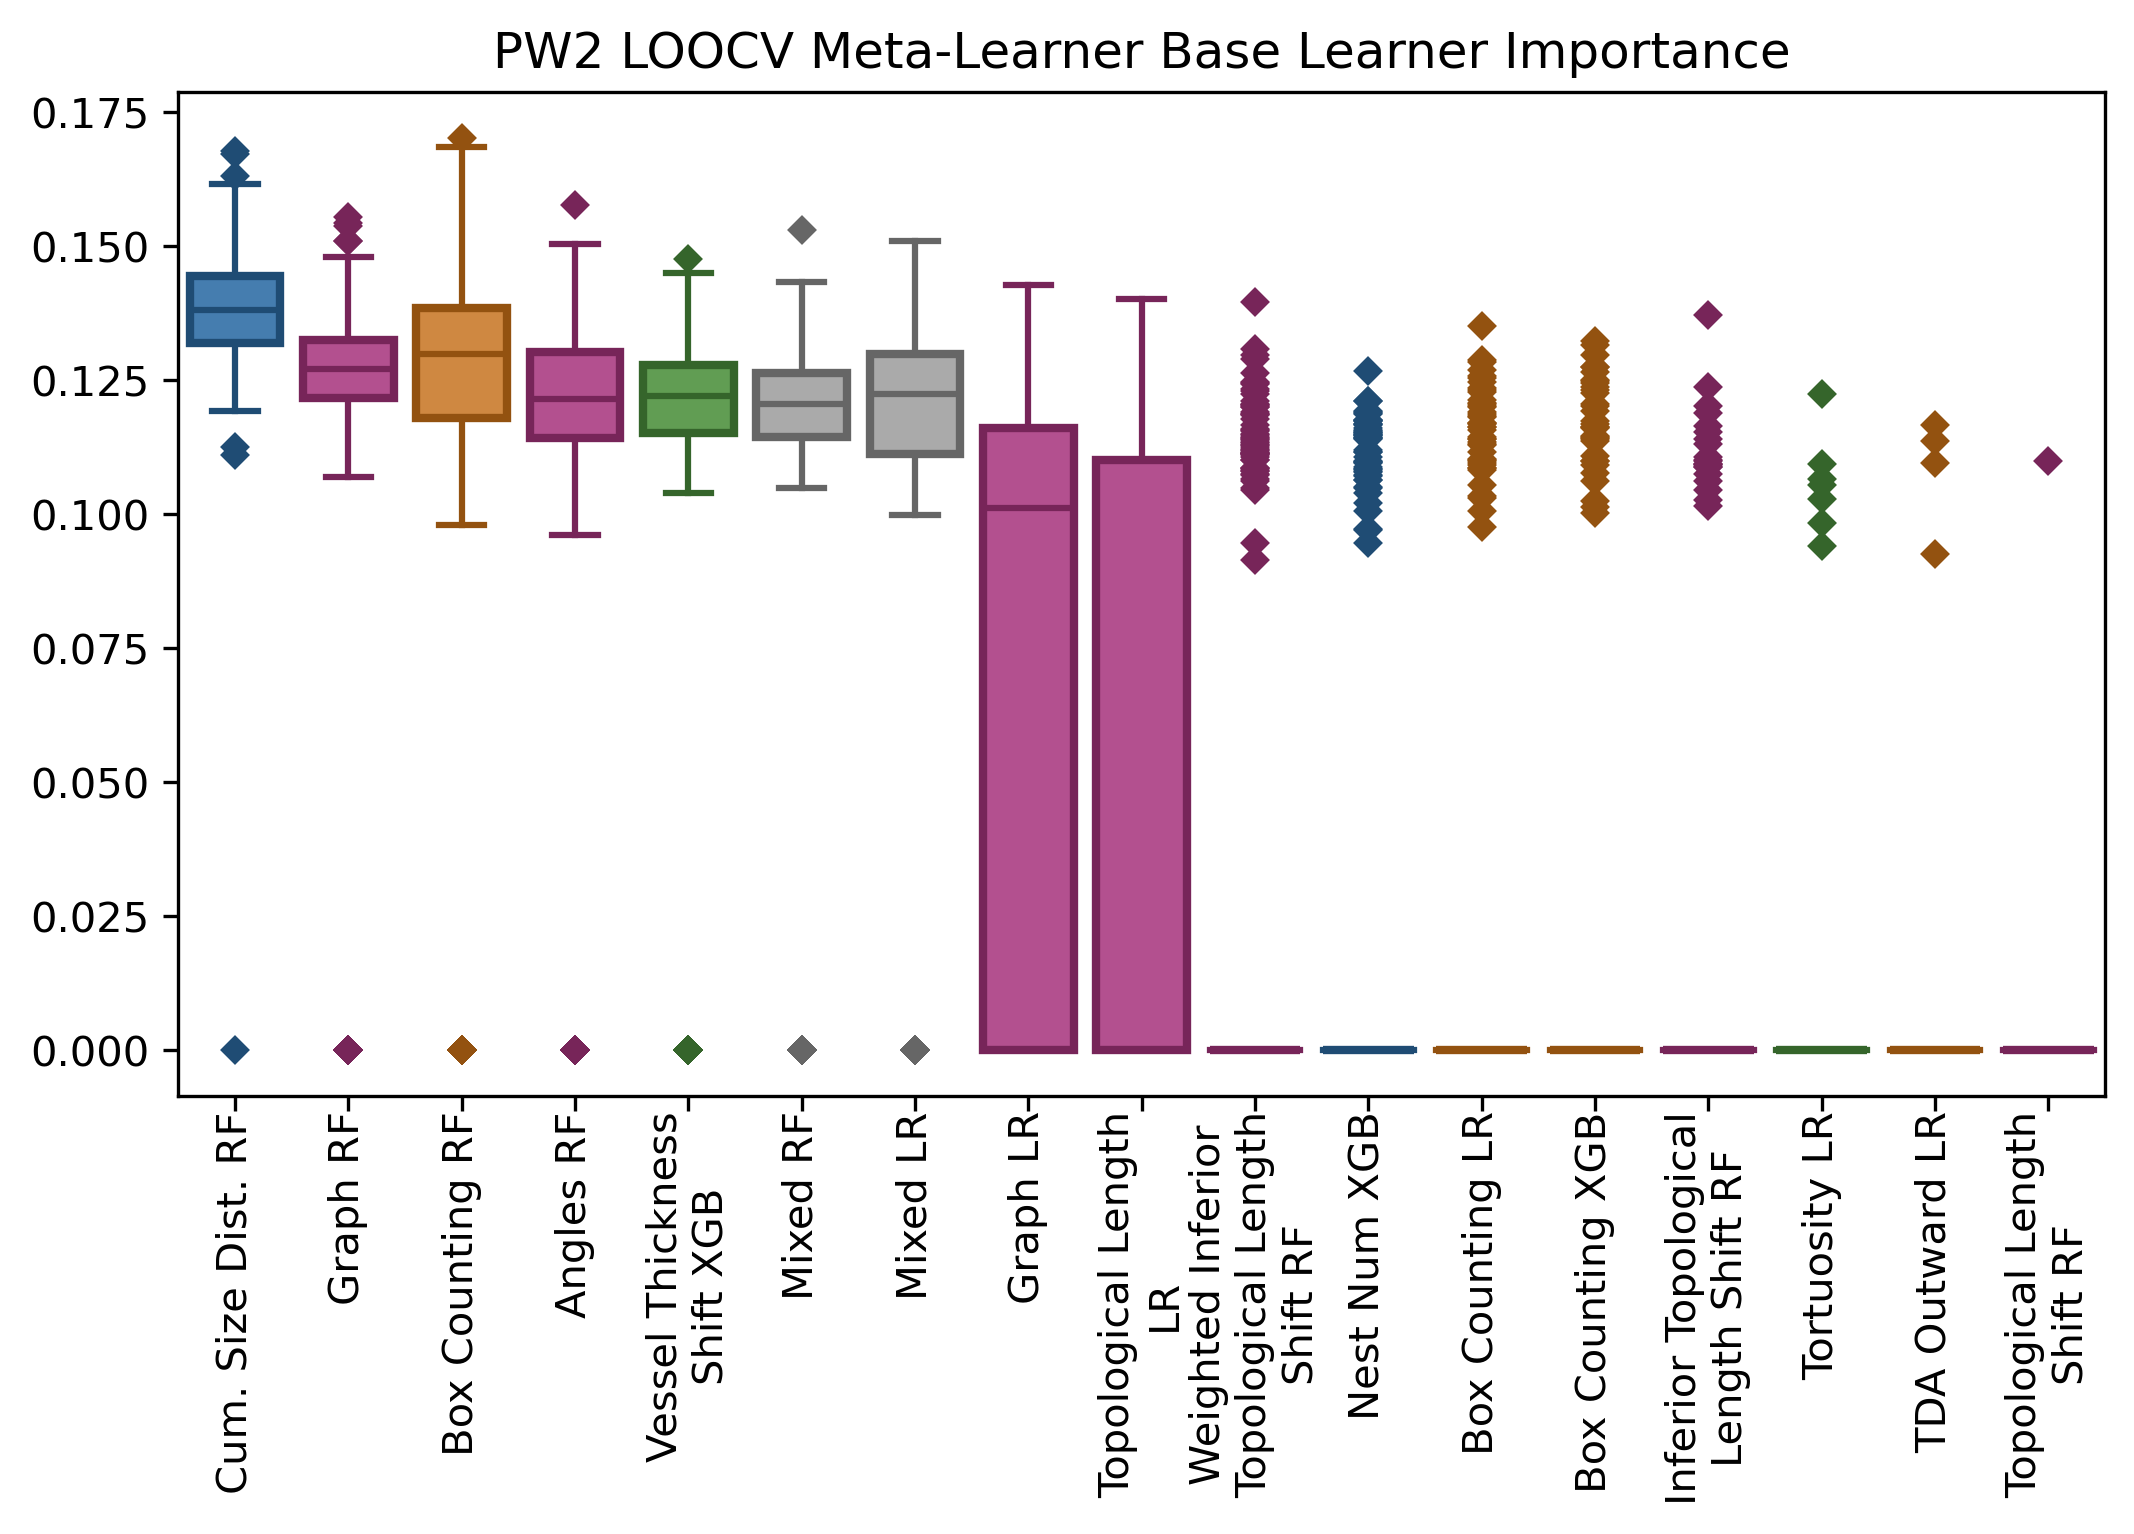

PW3
{n_estimators_100,max_depth_3,learning_rate_0.1,subsample_1.0,scale_pos_weight_8,n_feats_8}
there are 277 ids
there are 277 feature imps
there are 19 columns


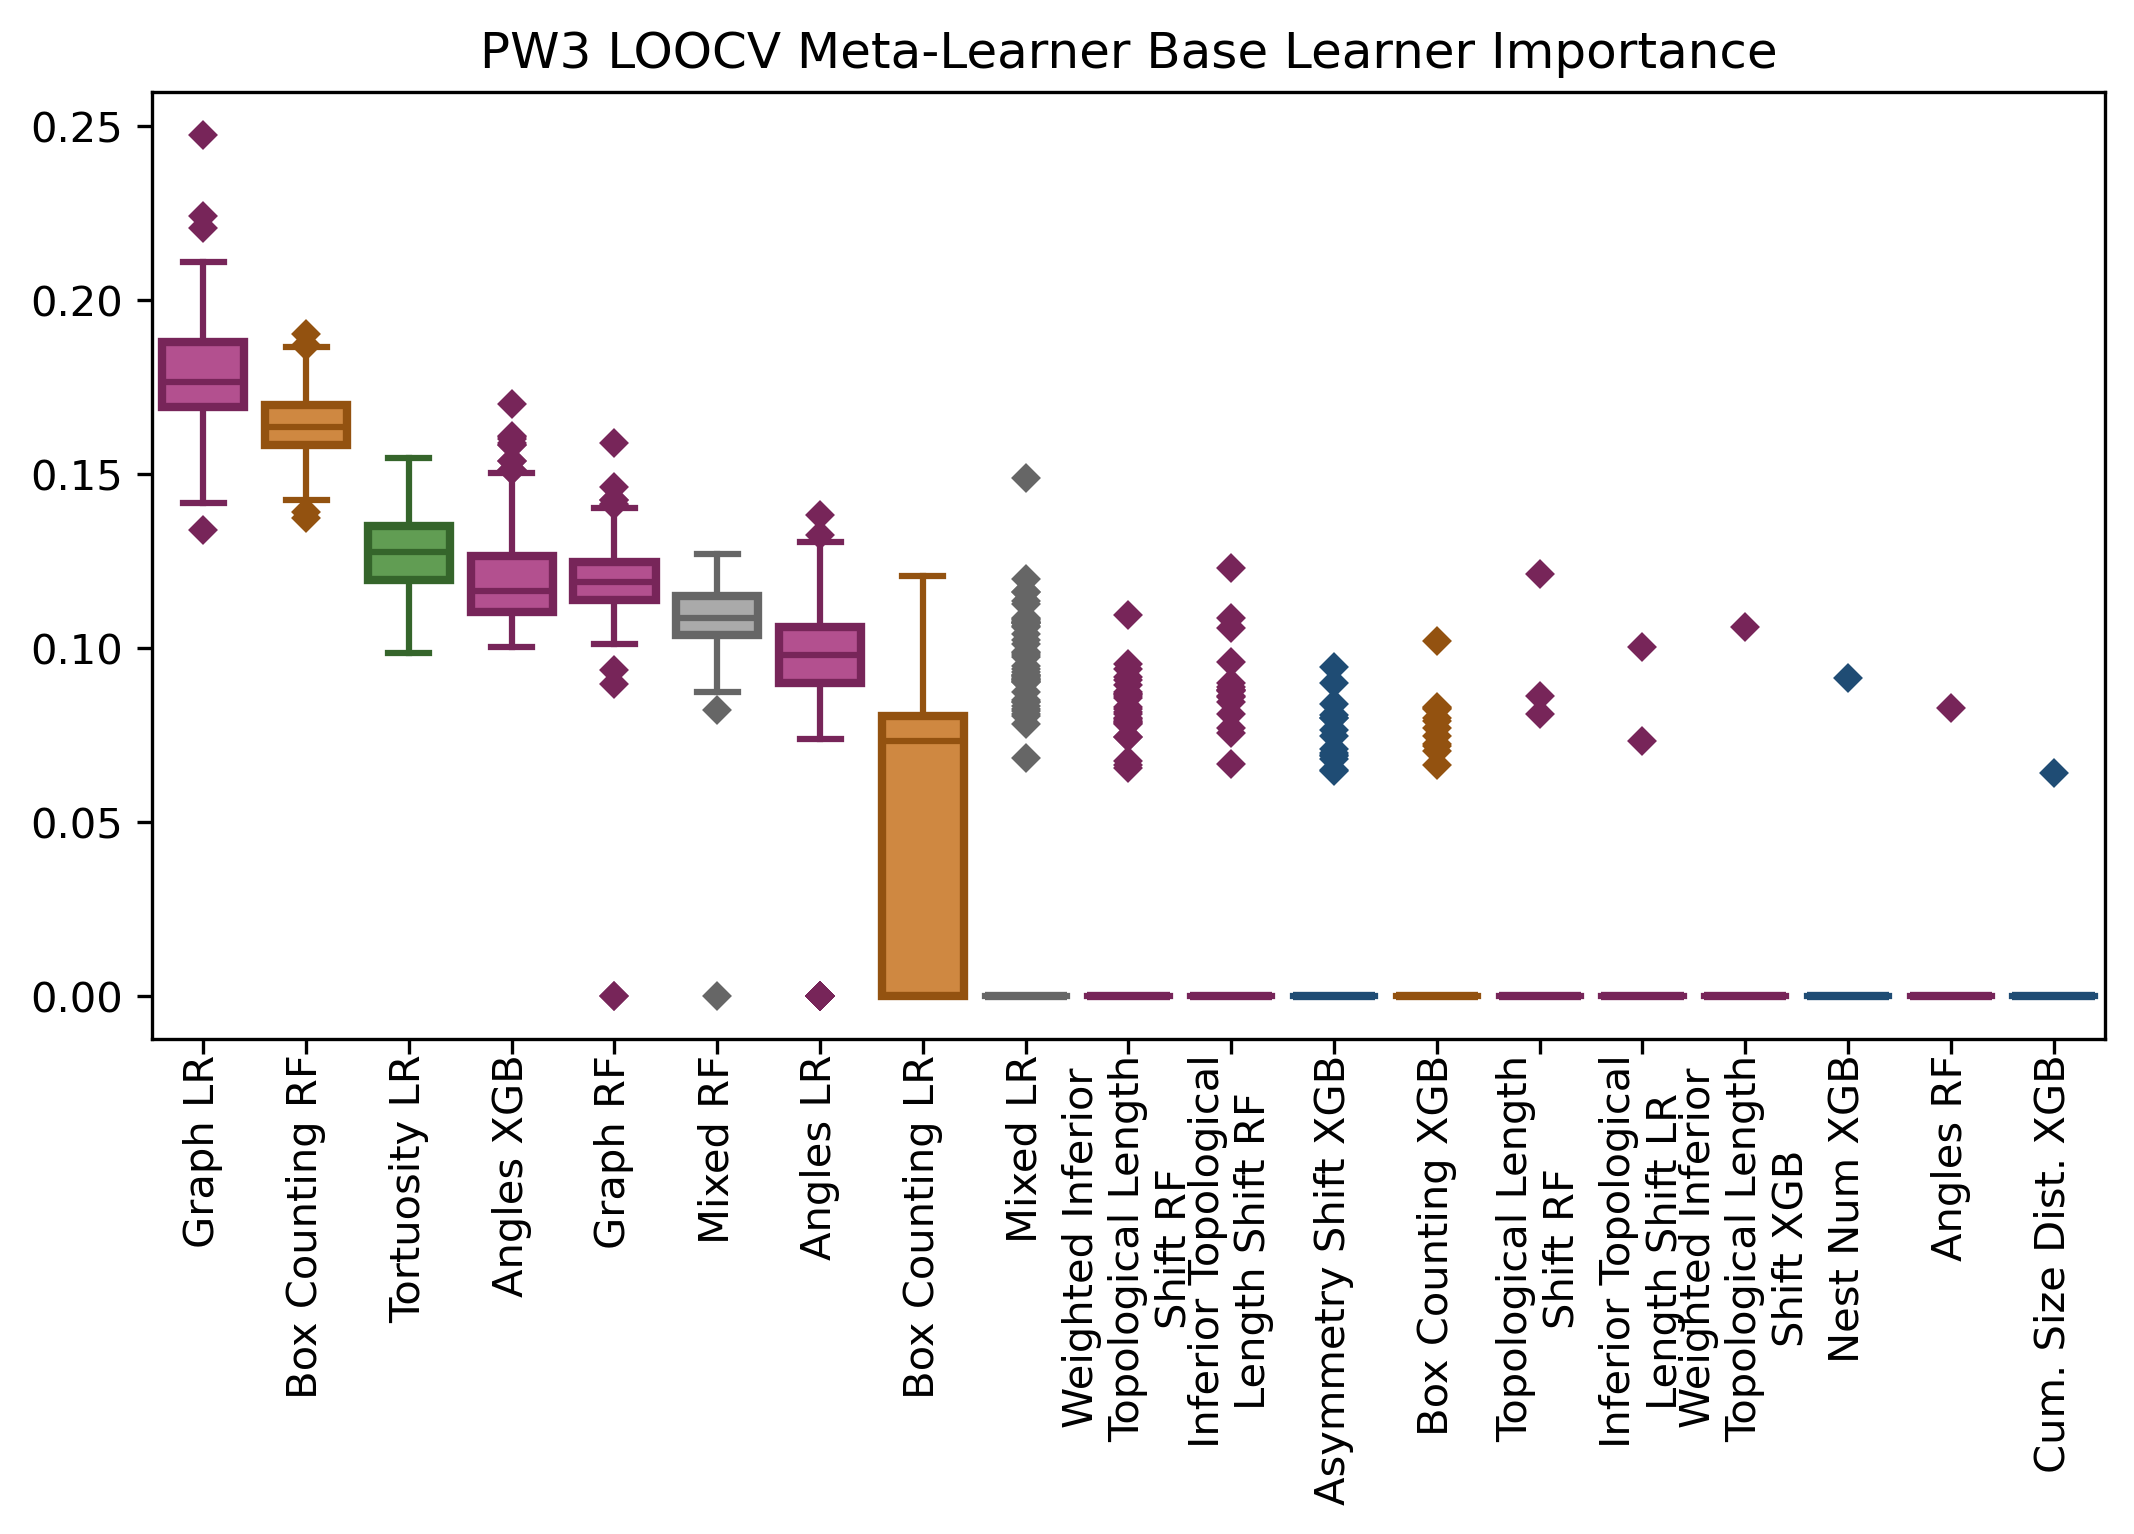

PW4
{n_estimators_250,max_depth_3,learning_rate_0.01,subsample_1.0,scale_pos_weight_12,n_feats_8}
there are 283 ids
there are 283 feature imps
there are 22 columns


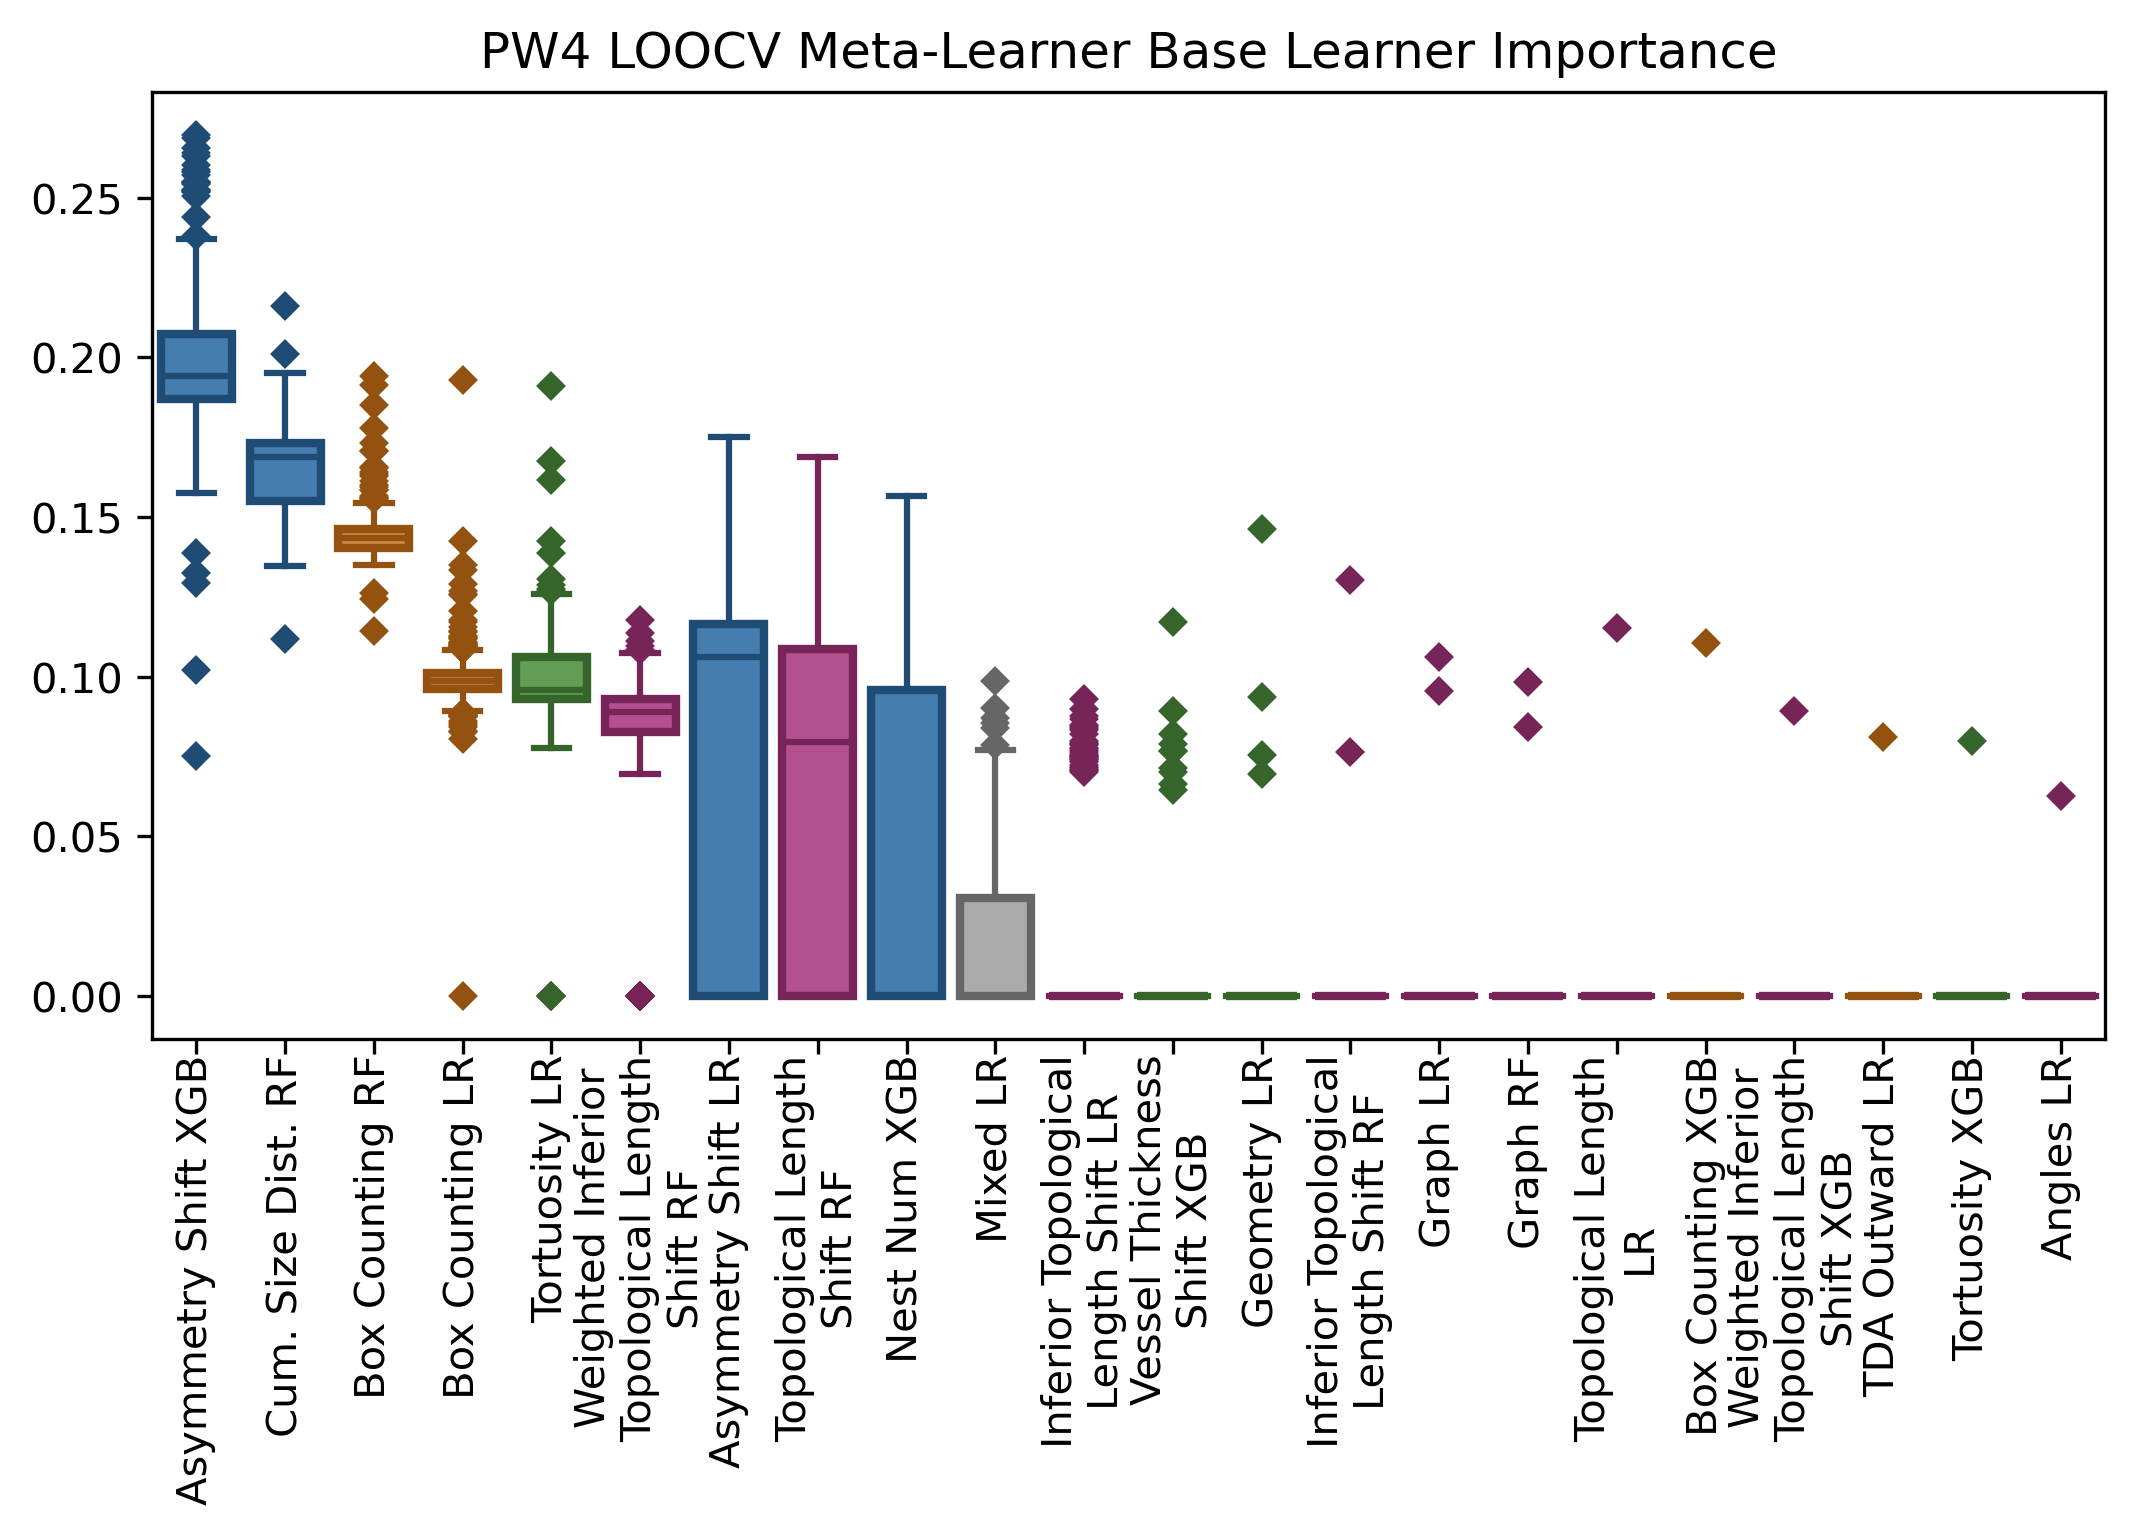

PW5
{n_estimators_250,max_depth_1,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_8}
there are 283 ids
there are 283 feature imps
there are 11 columns


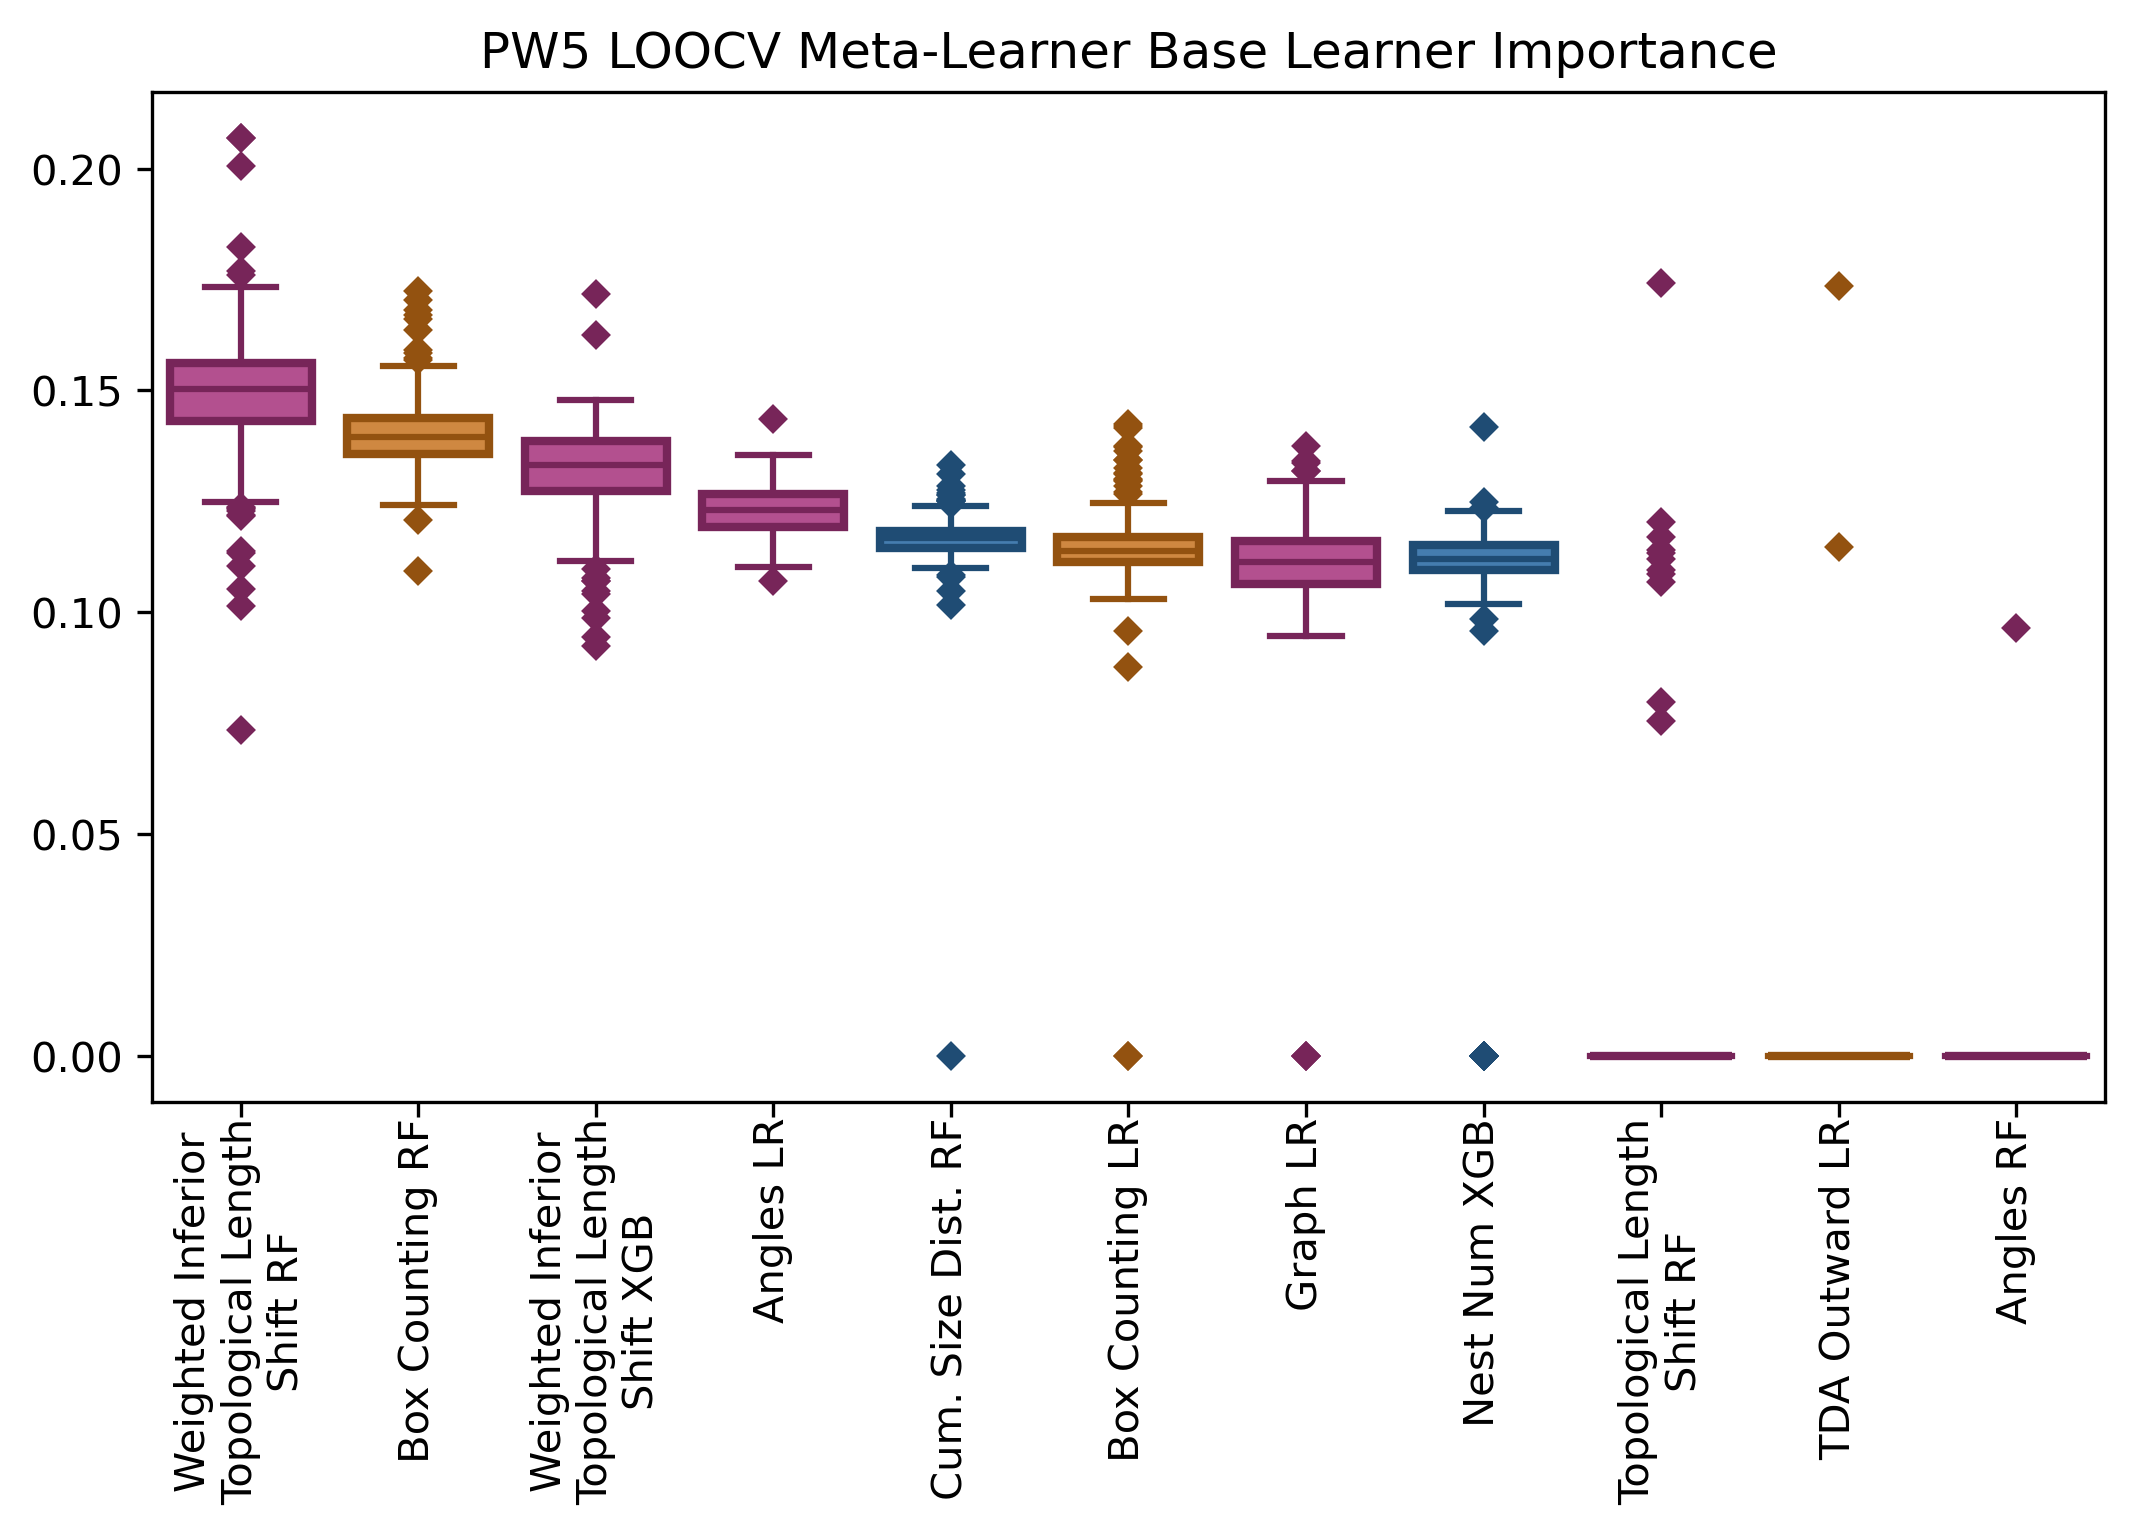

In [6]:
feats = get_pw_feat_imp_comps(data_name, run)